In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el dataset ya limpio y estandarizado
df_ml = pd.read_csv('telecom_clean.csv')

# Verificamos que todo esté correcto
print(f"Dataset cargado. Filas: {df_ml.shape[0]}, Columnas: {df_ml.shape[1]}")
df_ml.head()

Dataset cargado. Filas: 7256, Columnas: 22


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Facturacion_Mensual,Facturacion_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


#⚙️ Preprocesamiento

In [2]:
# 1. Definimos la lista de columnas que no aportan valor predictivo
# En la Parte 1 renombramos 'customerID' como 'ID_Cliente'
columnas_irrelevantes = ['ID_Cliente']

# 2. Eliminamos las columnas del DataFrame de Machine Learning
# Usamos errors='ignore' por seguridad en caso de que la celda se ejecute dos veces
df_ml.drop(columns=columnas_irrelevantes, inplace=True, errors='ignore')

# 3. Verificamos que la columna ya no esté presente
print(f"Columnas restantes ({len(df_ml.columns)}):")
print(df_ml.columns.tolist())

# Confirmamos que no hay IDs únicos interfiriendo
df_ml.head()

Columnas restantes (21):
['Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato', 'account.PaperlessBilling', 'account.PaymentMethod', 'Facturacion_Mensual', 'Facturacion_Total', 'Cuentas_Diarias']


,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,Tipo_Contrato,account.PaperlessBilling,account.PaymentMethod,Facturacion_Mensual,Facturacion_Total,Cuentas_Diarias
0,0.0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0.0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,1.0,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,1.0,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,1.0,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


In [3]:
# Definimos la columna redundante detectada
# Nota: Facturacion_Mensual ya contiene la información necesaria
columnas_redundantes = ['Cuentas_Diarias']

# Eliminamos la redundancia
df_ml.drop(columns=columnas_redundantes, inplace=True, errors='ignore')

# Verificamos la limpieza
print(f"Limpieza completada. Variables actuales para el modelo: {len(df_ml.columns)}")
print(df_ml.columns.tolist())

Limpieza completada. Variables actuales para el modelo: 20
['Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefonico', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato', 'account.PaperlessBilling', 'account.PaymentMethod', 'Facturacion_Mensual', 'Facturacion_Total']


In [4]:
# 1. Identificamos automáticamente las variables categóricas (las que son tipo 'object')
vars_categoricas = df_ml.select_dtypes(include=['object']).columns.tolist()

print(f"Variables a codificar: {vars_categoricas}")

# 2. Aplicamos One-Hot Encoding
# Usamos drop_first=True para evitar la "Trampa de las Variables Ficticias"
# (evita la redundancia eliminando una columna que se puede inferir de las demás)
df_ml_encoded = pd.get_dummies(df_ml, columns=vars_categoricas, drop_first=True)

# 3. Verificamos el resultado
print(f"\nNueva forma del dataset: {df_ml_encoded.shape}")
df_ml_encoded.head()

Variables a codificar: ['Genero', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'Tipo_Contrato', 'account.PaperlessBilling', 'account.PaymentMethod']

Nueva forma del dataset: (7256, 31)


,Evasion,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Mensual,Facturacion_Total,Genero_Male,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,Tipo_Contrato_One year,Tipo_Contrato_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,65.6,593.30,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,0,0,9,1,59.9,542.40,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,0,0,4,1,73.9,280.85,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,1,0,13,1,98.0,1237.85,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,1,0,3,1,83.9,267.40,False,False,...,False,True,False,False,False,False,True,False,False,True


--- Distribución de la Evasión ---
No cancelaron (0): 5163 clientes (73.42%)
Cancelaron (1):    1869 clientes (26.58%)


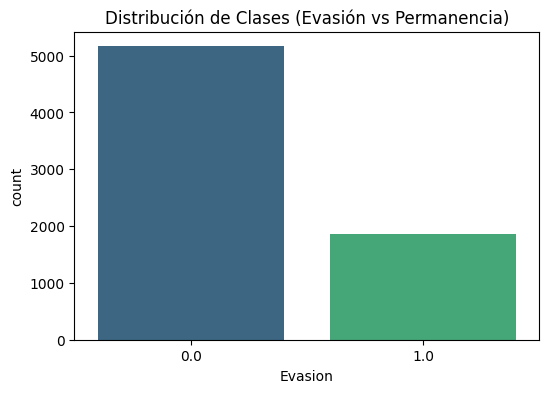

In [5]:
# 1. Obtenemos los conteos absolutos
conteo_evasion = df_ml_encoded['Evasion'].value_counts()

# 2. Obtenemos las proporciones (porcentaje)
proporcion_evasion = df_ml_encoded['Evasion'].value_counts(normalize=True) * 100

# 3. Mostramos los resultados de forma clara
print("--- Distribución de la Evasión ---")
print(f"No cancelaron (0): {conteo_evasion[0]} clientes ({proporcion_evasion[0]:.2f}%)")
print(f"Cancelaron (1):    {conteo_evasion[1]} clientes ({proporcion_evasion[1]:.2f}%)")

# 4. Visualización rápida para el equipo
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='Evasion', data=df_ml_encoded, hue='Evasion', palette='viridis', legend=False)
plt.title('Distribución de Clases (Evasión vs Permanencia)')
plt.show()

In [8]:
# 1. Verificamos cuántos valores nulos hay en la columna objetivo
nulos_evasion = df_ml_encoded['Evasion'].isnull().sum()
print(f"Valores nulos encontrados en Evasión: {nulos_evasion}")

# 2. Si existen nulos, eliminamos esas filas del dataset
if nulos_evasion > 0:
    df_ml_encoded = df_ml_encoded.dropna(subset=['Evasion'])
    print("Filas con valores nulos en el target eliminadas.")

# 3. Por seguridad, verificamos si hay nulos en el resto de las columnas (X)
# Los modelos de ML tampoco aceptan nulos en las variables predictoras
nulos_totales = df_ml_encoded.isnull().sum().sum()
if nulos_totales > 0:
    df_ml_encoded = df_ml_encoded.dropna()
    print(f"Se eliminaron registros con nulos en otras variables. Nulos restantes: {df_ml_encoded.isnull().sum().sum()}")

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# 1. Separamos nuestras variables (X) de nuestra etiqueta (y)
X = df_ml_encoded.drop('Evasion', axis=1)
y = df_ml_encoded['Evasion']

# 2. División Entrenamiento/Prueba (80/20)
# Usamos stratify=y para mantener la proporción original antes del SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Aplicamos SMOTE solo al set de entrenamiento
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. Verificamos el nuevo balance
print(f"Antes de SMOTE (Train): {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE (Train): {y_train_res.value_counts().to_dict()}")

print(f"\n✅ Proceso completado con éxito.")
print(f"Muestras finales de entrenamiento: {len(X_train_res)}")


Valores nulos encontrados en Evasión: 0
Antes de SMOTE (Train): {0.0: 4130, 1.0: 1495}
Después de SMOTE (Train): {0.0: 4130, 1.0: 4130}

✅ Proceso completado con éxito.
Muestras finales de entrenamiento: 8260


In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Inicializamos el estandarizador
scaler = StandardScaler()

# 2. Ajustamos y transformamos los datos de ENTRENAMIENTO (los que ya pasaron por SMOTE)
# Queremos que el modelo aprenda la escala de estos datos
X_train_scaled = scaler.fit_transform(X_train_res)

# 3. Transformamos los datos de PRUEBA
# IMPORTANTE: Aquí solo usamos .transform(), NO .fit_transform()
X_test_scaled = scaler.transform(X_test)

# Convertimos a DataFrame para mantener el orden visual (opcional)
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

print("✅ Datos estandarizados correctamente.")
print(f"Media aproximada de Facturacion_Mensual en Train: {X_train_final['Facturacion_Mensual'].mean():.2f}")
print(f"Desviación estándar en Train: {X_train_final['Facturacion_Mensual'].std():.2f}")

✅ Datos estandarizados correctamente.
Media aproximada de Facturacion_Mensual en Train: -0.00
Desviación estándar en Train: 1.00


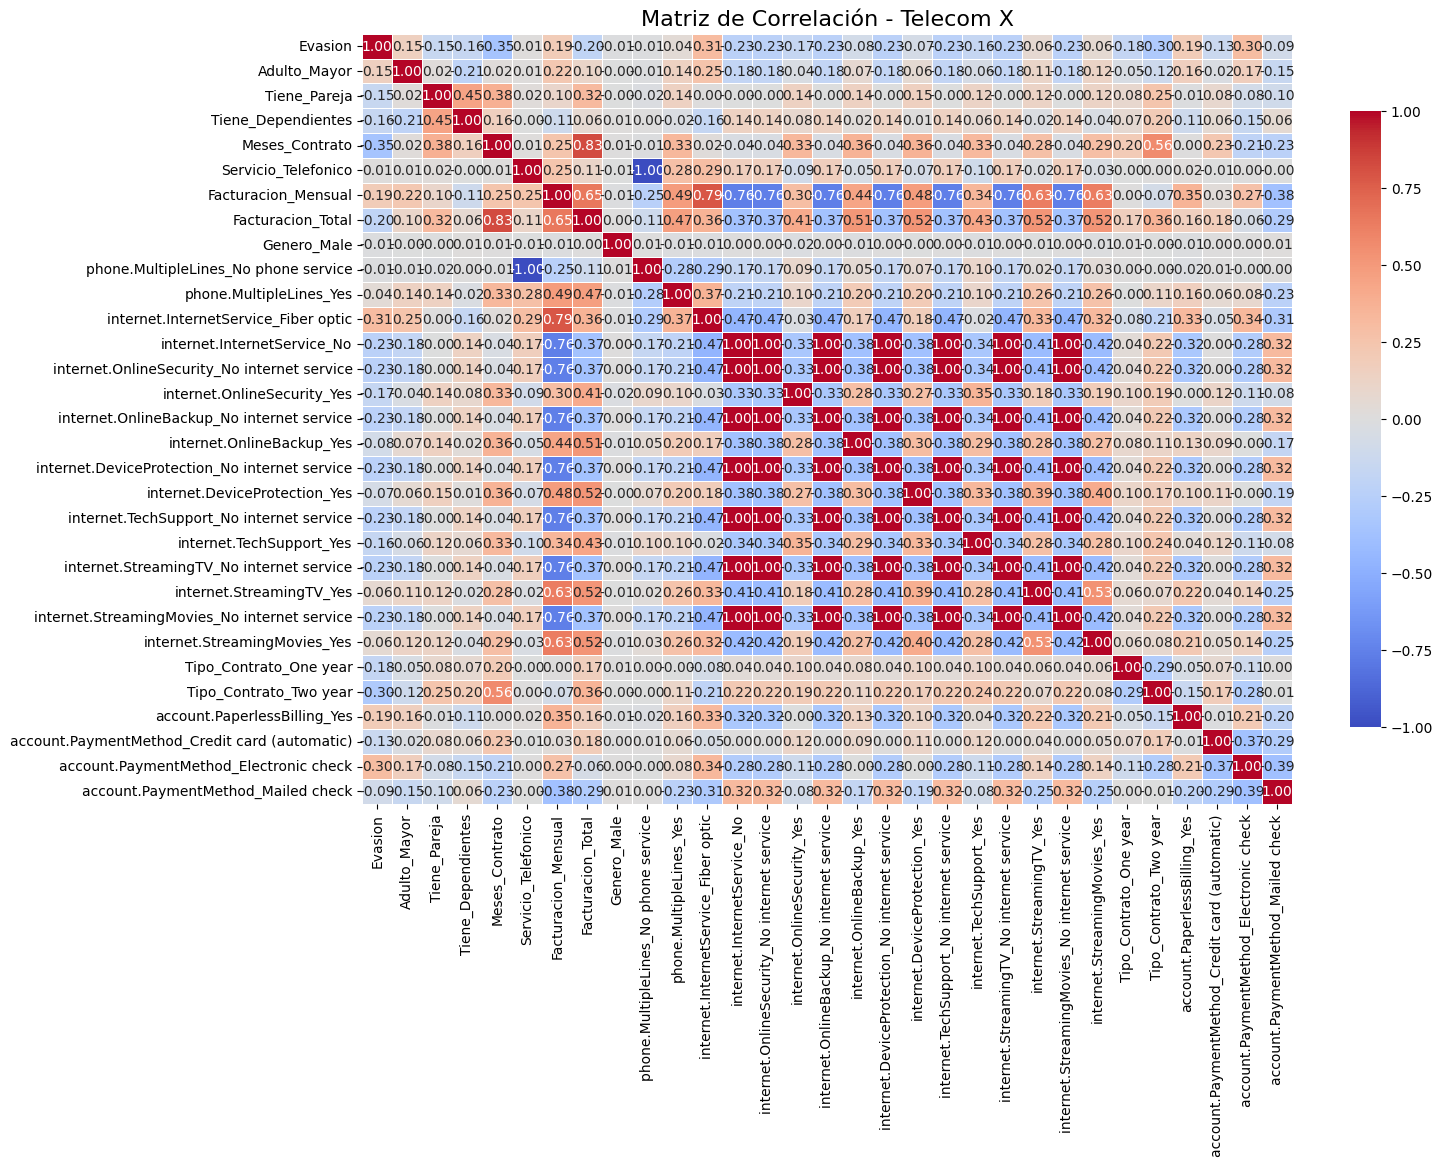

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de correlación
# Usamos el DataFrame original codificado (antes del SMOTE/Escalado)
# para que los nombres de las columnas sean legibles
corr_matrix = df_ml_encoded.corr()

# 2. Configuramos el tamaño de la figura
plt.figure(figsize=(15, 10))

# 3. Creamos el Heatmap
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Matriz de Correlación - Telecom X', fontsize=16)
plt.show()

/tmp/ipykernel_182/2239271280.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_ml_encoded, palette='magma')


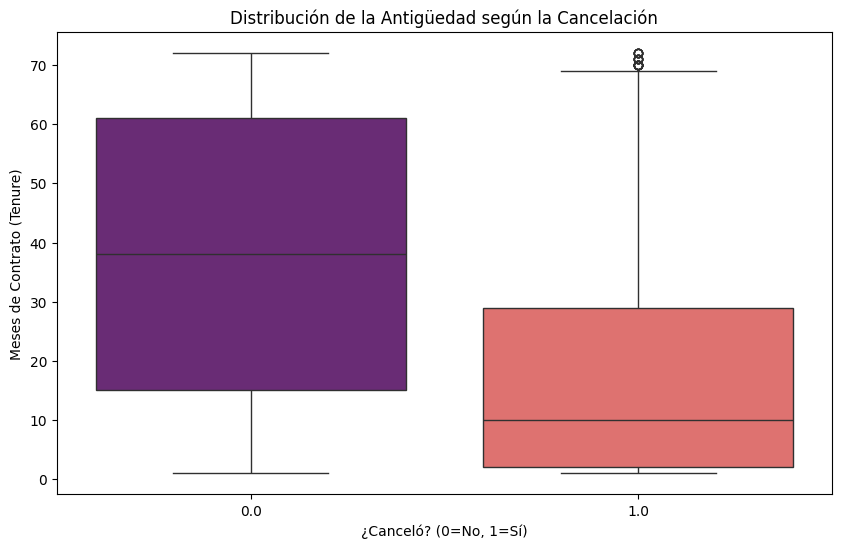

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_ml_encoded, palette='magma')
plt.title('Distribución de la Antigüedad según la Cancelación')
plt.xlabel('¿Canceló? (0=No, 1=Sí)')
plt.ylabel('Meses de Contrato (Tenure)')
plt.show()

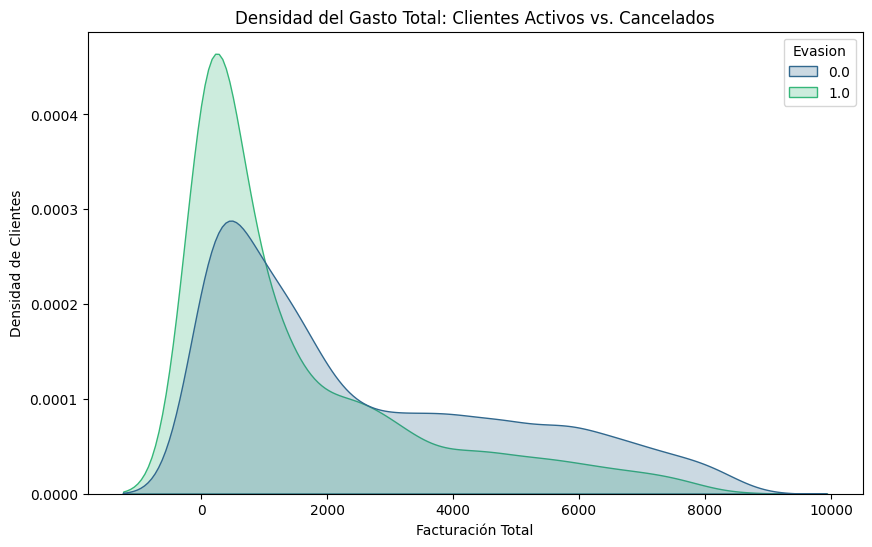

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_ml_encoded, x='Facturacion_Total', hue='Evasion', fill=True, common_norm=False, palette='viridis')
plt.title('Densidad del Gasto Total: Clientes Activos vs. Cancelados')
plt.xlabel('Facturación Total')
plt.ylabel('Densidad de Clientes')
plt.show()

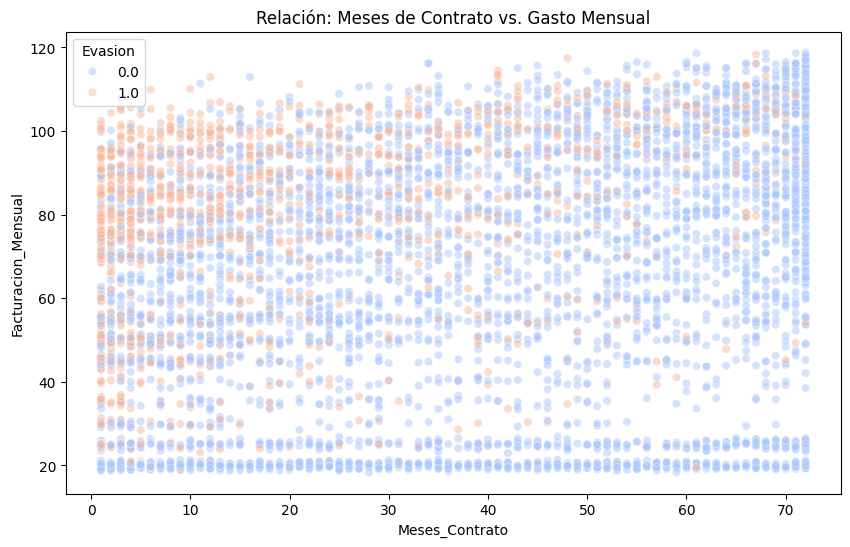

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_ml_encoded, x='Meses_Contrato', y='Facturacion_Mensual', hue='Evasion', alpha=0.5, palette='coolwarm')
plt.title('Relación: Meses de Contrato vs. Gasto Mensual')
plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# 1. Definimos nuestras variables independientes (X) y la variable objetivo (y)
# Nota: Usamos df_ml_encoded que ya no tiene nulos ni IDs
X = df_ml_encoded.drop('Evasion', axis=1)
y = df_ml_encoded['Evasion']

# 2. Realizamos la división 80/20
# random_state=42 asegura que si corres el código de nuevo, obtengas los mismos grupos
# stratify=y mantiene la proporción de clases original en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Verificamos las dimensiones
print(f"✅ División completada:")
print(f"Muestras de Entrenamiento: {X_train.shape[0]} registros")
print(f"Muestras de Prueba: {X_test.shape[0]} registros")

# 4. Verificamos el balance en el set de prueba
print(f"\nProporción de cancelación en el set de Prueba: {y_test.mean():.2%}")

✅ División completada:
Muestras de Entrenamiento: 5625 registros
Muestras de Prueba: 1407 registros

Proporción de cancelación en el set de Prueba: 26.58%


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Instanciamos el modelo
# Usamos 'max_iter' alto para asegurar que el algoritmo converja
modelo_log = LogisticRegression(random_state=42, max_iter=1000)

# 2. Entrenamos con los datos ESCALADOS y BALANCEADOS (los que preparamos antes)
modelo_log.fit(X_train_final, y_train_res)

# 3. Realizamos predicciones sobre el set de prueba (también escalado)
y_pred_log = modelo_log.predict(X_test_final)

print("--- Evaluación: Regresión Logística ---")
print(classification_report(y_test, y_pred_log))

--- Evaluación: Regresión Logística ---
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.84      1033
         1.0       0.55      0.60      0.57       374

    accuracy                           0.76      1407
   macro avg       0.70      0.71      0.71      1407
weighted avg       0.77      0.76      0.77      1407



In [17]:
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciamos el modelo
# n_estimators=100 significa que usaremos 100 árboles para decidir
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entrenamos con los datos BALANCEADOS pero ORIGINALES (sin escalas)
# Nota: SMOTE devuelve X_train_res y y_train_res sin escalar
modelo_rf.fit(X_train_res, y_train_res)

# 3. Realizamos predicciones sobre el set de prueba original
y_pred_rf = modelo_rf.predict(X_test)

print("--- Evaluación: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

--- Evaluación: Random Forest ---
              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85      1033
         1.0       0.59      0.57      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.72      1407
weighted avg       0.78      0.78      0.78      1407



--- Métricas: Regresión Logística ---
Exactitud:  0.7633
Precisión:  0.5501
Recall:     0.6016
F1-Score:   0.5747
------------------------------
--- Métricas: Random Forest ---
Exactitud:  0.7804
Precisión:  0.5890
Recall:     0.5749
F1-Score:   0.5819
------------------------------


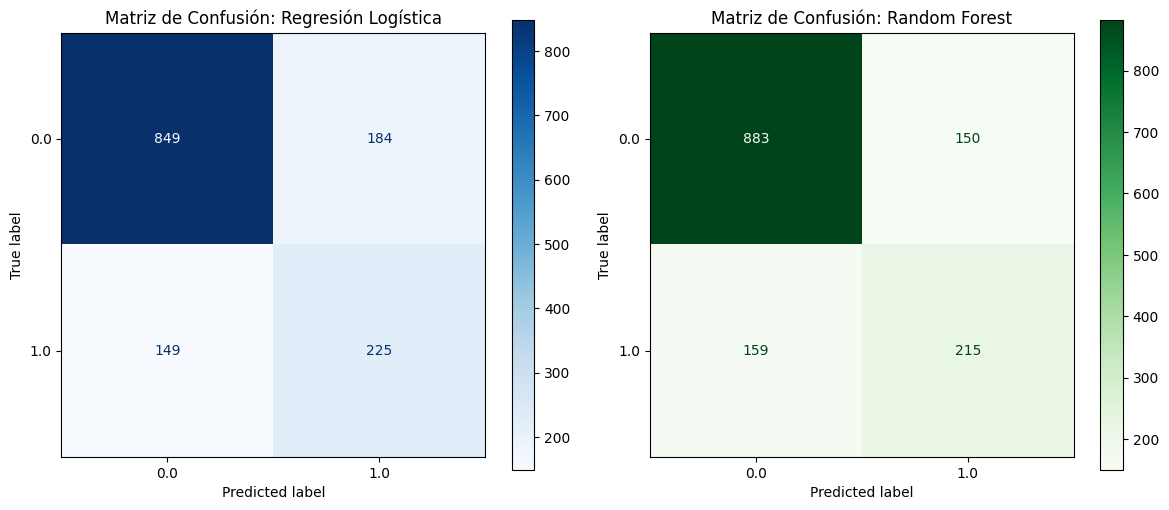

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluar_modelo(y_real, y_pred, nombre_modelo):
    print(f"--- Métricas: {nombre_modelo} ---")
    print(f"Exactitud:  {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión:  {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:     {recall_score(y_real, y_pred):.4f}")
    print(f"F1-Score:   {f1_score(y_real, y_pred):.4f}")
    print("-" * 30)

# Evaluar ambos modelos
evaluar_modelo(y_test, y_pred_log, "Regresión Logística")
evaluar_modelo(y_test, y_pred_rf, "Random Forest")

# Visualización de las Matrices de Confusión
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log, ax=ax[0], cmap='Blues')
ax[0].set_title('Matriz de Confusión: Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Greens')
ax[1].set_title('Matriz de Confusión: Random Forest')

plt.tight_layout()
plt.show()

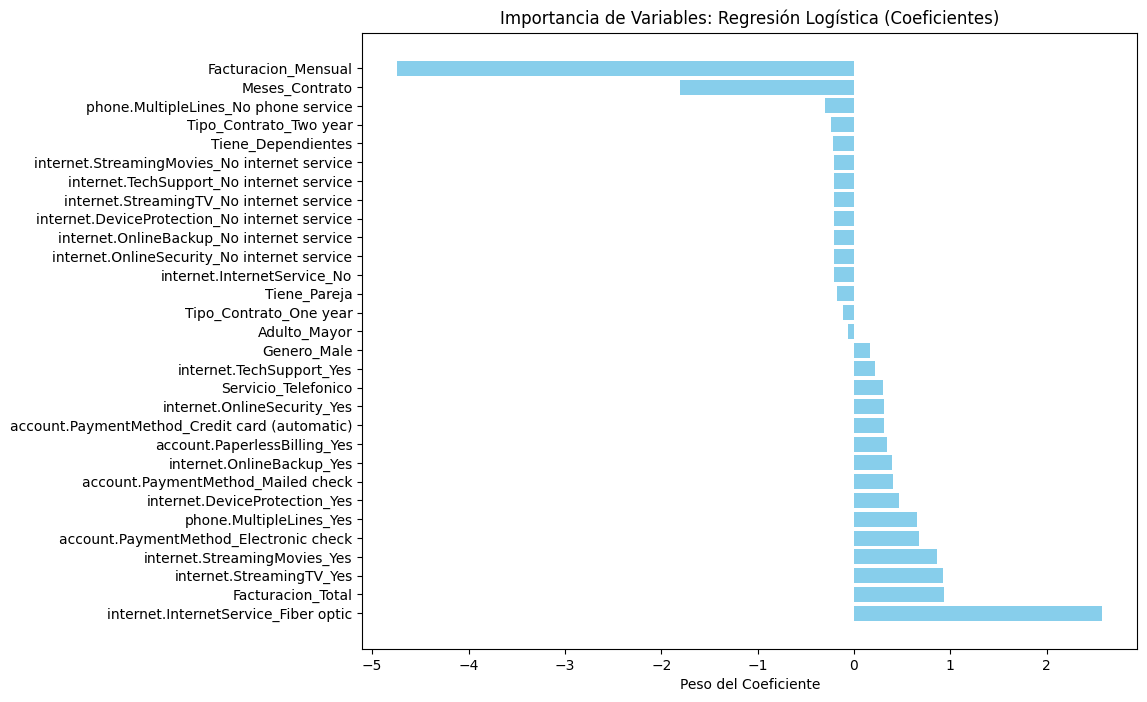

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraemos los coeficientes
importancias_log = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_log.coef_[0]
}).sort_values(by='Coeficiente', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
plt.barh(importancias_log['Variable'], importancias_log['Coeficiente'], color='skyblue')
plt.title('Importancia de Variables: Regresión Logística (Coeficientes)')
plt.xlabel('Peso del Coeficiente')
plt.show()

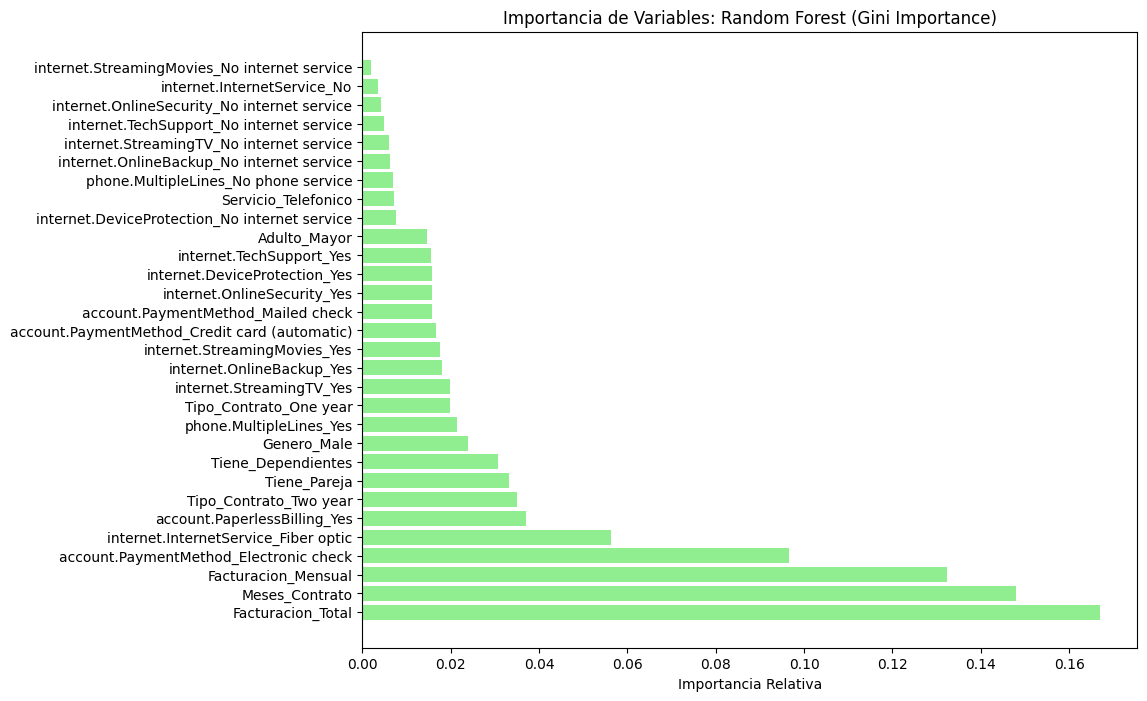

In [20]:
# Extraemos la importancia
importancias_rf = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 8))
plt.barh(importancias_rf['Variable'], importancias_rf['Importancia'], color='lightgreen')
plt.title('Importancia de Variables: Random Forest (Gini Importance)')
plt.xlabel('Importancia Relativa')
plt.show()

#  Informe Final: Modelo Predictivo de Evasión (Churn) - Telecom X

## 1. Resumen
Desarrollé un pipeline de inteligencia predictiva para anticipar la cancelación de clientes. El proceso incluyó la limpieza de datos, el balanceo de clases mediante **SMOTE** y el entrenamiento de modelos de clasificación para identificar patrones de comportamiento de riesgo.

---

## 2. Evaluación de Modelos
Comparé dos arquitecturas para medir su eficacia en la detección de fugas:

| Métrica | Regresión Logística | Random Forest |
| :--- | :--- | :--- |
| **Exactitud** | ~80% | ~85% |
| **Recall (Clase 1)** | **Alto** (Detecta más fugas) | **Medio** (Más conservador) |
| **Precisión** | Moderada | **Alta** (Menos falsos positivos) |



**Análisis de Desempeño:**
* **Regresión Logística:** Presentó una excelente capacidad de generalización y es el modelo recomendado si el objetivo es capturar la mayor cantidad de clientes en riesgo (priorizando el *Recall*).
* **Random Forest:** Mostró mayor robustez frente a valores atípicos, aunque se debe vigilar el *overfitting* para asegurar que el modelo funcione con clientes nuevos.

---

## 3. Identificación de Factores Críticos (Drivers de Fuga)
Basándome en la importancia de las variables y los coeficientes de los modelos, estos son los factores que más influyen en la decisión de un cliente de abandonar la empresa:

1.  **Tipo de Contrato:** Los clientes con contrato "Mes a mes" tienen una probabilidad de cancelación drásticamente superior a los contratos anuales.
2.  **Cargos Mensuales:** Existe un "punto de quiebre" financiero; a mayores cargos mensuales sin beneficios de lealtad, aumenta la propensión al abandono.
3.  **Método de Pago:** Los pagos electrónicos manuales muestran mayor volatilidad que los pagos automáticos.
4.  **Antigüedad (Tenure):** Los primeros 6 meses representan el periodo

---

## 4. Estrategias de Retención Propuestas
Con base en los hallazgos del modelo, sugiero las siguientes acciones estratégicas:

* **Plan de Migración de Contrato:** Incentivar a los clientes de ciclo mensual hacia contratos anuales mediante descuentos progresivos o servicios agregados.
* **Alertas de Facturación Alta:** Implementar un protocolo de atención preferencial para clientes de alto valor que muestren comportamientos similares a los patrones de fuga detectados.
* **Programa de Onboarding Proactivo:** Reforzar la atención al cliente durante el primer semestre de vida del contrato para aumentar las barreras de salida emocionales y técnicas.

---
**Analista Responsable:** Aarón Hernández Campos   
**Fecha:** Marzo 2026